Zadanie 11

Dataset: Titanic

Wymagania:
- Znajdź pasażerów 1 klasy, kobiety, które przeżyły
- Oblicz średni wiek i średnią cenę biletu dla tej grupy
- Porównaj z mężczyznami z 3 klasy którzy nie przeżyli
- Stwórz wykres porównawczy (barplot)

Przeżywalność: kobiety w 1 klasie: 
                                                 Name     Sex  Pclass  \
0   Cumings, Mrs. John Bradley (Florence Briggs Th...  female       1   
1        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female       1   
2                            Bonnell, Miss. Elizabeth  female       1   
3      Spencer, Mrs. William Augustus (Marie Eugenie)  female       1   
4            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female       1   
..                                                ...     ...     ...   
86         Wick, Mrs. George Dennick (Mary Hitchcock)  female       1   
87  Swift, Mrs. Frederick Joel (Margaret Welles Ba...  female       1   
88   Beckwith, Mrs. Richard Leonard (Sallie Monypeny)  female       1   
89      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  female       1   
90                       Graham, Miss. Margaret Edith  female       1   

    Survived  
0          1  
1          1  
2          1  
3          1  
4          1

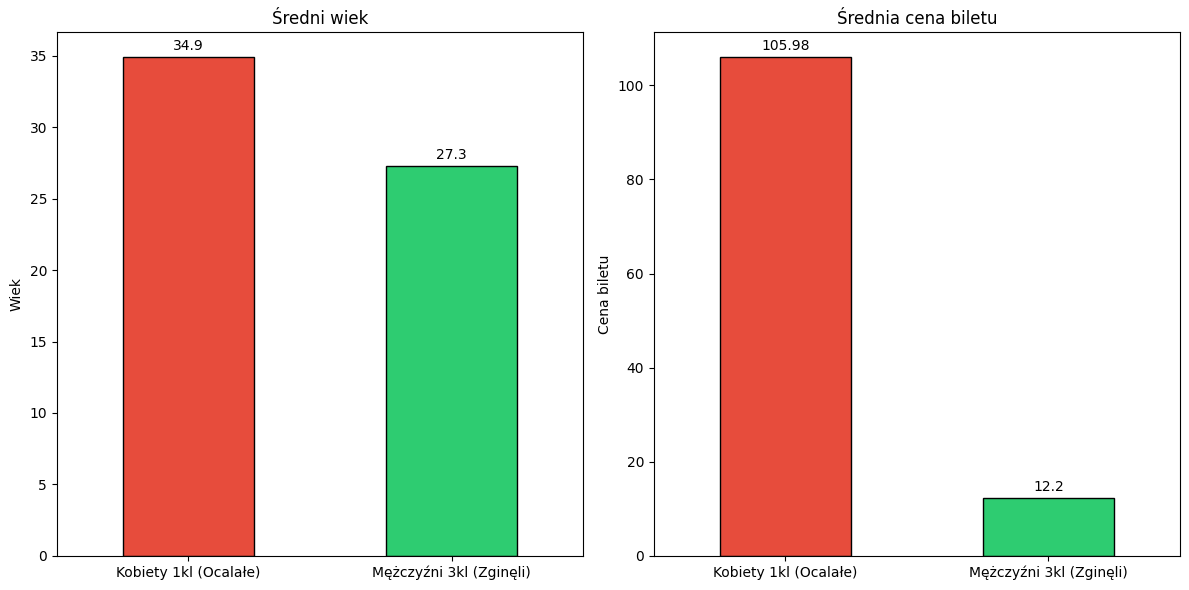

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

# Tworzenie bazy
conn = sqlite3.connect('titanic.db')
titanic.to_sql('passengers', conn, if_exists='replace', index=False)

# Tworzenie indeksów
conn.execute("CREATE INDEX idx_survived ON passengers(Survived)")
conn.execute("CREATE INDEX idx_pclass ON passengers(Pclass)")
conn.execute("CREATE INDEX idx_sex ON passengers(Sex)")
conn.execute("CREATE INDEX idx_fare ON passengers(Fare)")
conn.execute("CREATE INDEX idx_age ON passengers(Age)")

# Znalezienie pasażerów 1 klasy, kobiety, które przeżyły
query = """
SELECT
    Name,
    Sex,
    Pclass,
    Survived
FROM passengers
WHERE Pclass = 1 AND (Sex = 'female' AND Survived=1)
"""

survival = pd.read_sql_query(query, conn)
print("Przeżywalność: kobiety w 1 klasie: ")
print(survival)

# Obliczenie średniego wieku i średniej ceny biletu dla tej grupy
query = """
SELECT
    Sex,
    Pclass,
    Survived,
    ROUND(AVG(Age), 1) AS avg_age,
    ROUND(AVG(Fare), 2) AS avg_fare
FROM passengers
WHERE Pclass = 1 AND (Sex = 'female' AND Survived=1)
GROUP BY Survived

"""

survival = pd.read_sql_query(query, conn)
print("Statystyki przeżywalności (Ocalałe kobiety w 1 klasie vs Nieocaleni mężczyźni w 3 klasie):")
print(survival)

# Porównanie z mężczyznami z 3 klasy którzy nie przeżyli
query = """
SELECT
    Sex,
    Pclass,    
    CASE 
        WHEN Pclass = 1 AND Sex = 'female' AND Survived = 1 THEN 'Kobiety 1kl (Ocalałe)'
        WHEN Pclass = 3 AND Sex = 'male' AND Survived = 0 THEN 'Mężczyźni 3kl (Zginęli)'
    END AS status,
    ROUND(AVG(Age), 1) AS avg_age,
    ROUND(AVG(Fare), 2) AS avg_fare
FROM passengers
WHERE (Pclass = 1 AND Sex = 'female' AND Survived=1) OR (Pclass = 3 AND Sex = 'male' AND Survived=0)
GROUP BY status
"""

survival_stats = pd.read_sql_query(query, conn)
print("Przeżywalność: kobiety w 1 klasie; średni wiek, średnia cena biletu: ")
print(survival_stats)



# Wykres porównawczy (barplot)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
survival_stats = survival_stats.set_index('status')

# Wykres dla Wieku (avg_age)
survival_stats['avg_age'].plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax[0].set_title('Średni wiek')
ax[0].set_ylabel('Wiek')
ax[0].tick_params(axis='x', rotation=0)
ax[0].set_xlabel('')

# Wykres dla Ceny (avg_fare)
survival_stats['avg_fare'].plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax[1].set_title('Średnia cena biletu')
ax[1].set_ylabel('Cena biletu')
ax[1].tick_params(axis='x', rotation=0)
ax[1].set_xlabel('')

# Dodanie wartości nad słupkami
for a in ax:
    for container in a.containers:
        a.bar_label(container, padding=3)

plt.tight_layout()
plt.show()